# German Credit Risk Analysis: A Complete Machine Learning Pipeline

## Project Overview

This notebook presents a comprehensive analysis of the **Statlog (German Credit Data)** dataset from the UCI Machine Learning Repository. The primary objective is to build a robust binary classification model to predict credit risk (Good vs. Bad credit).

### Business Context
Credit risk assessment is crucial for financial institutions to minimize losses from loan defaults. By accurately identifying high-risk applicants, banks can make informed lending decisions, balancing profitability with risk management.

### Methodology
This analysis follows a structured approach:
1. **Data Acquisition & Understanding** - Loading and exploring the dataset
2. **Data Preprocessing** - Feature engineering and encoding
3. **Exploratory Data Analysis (EDA)** - Visualization and statistical analysis
4. **Feature Engineering** - Optimal binning with Weight of Evidence (WoE)
5. **Model Building** - Multiple classification algorithms
6. **Hyperparameter Optimization** - Using Optuna for automated tuning
7. **Model Evaluation** - Comprehensive performance metrics
8. **Feature Importance Analysis** - Understanding key predictors

---

**Author:** Data Science Portfolio Project  
**Dataset Source:** [UCI Machine Learning Repository - German Credit Data](https://archive.ics.uci.edu/ml/datasets/Statlog+%28German+Credit+Data%29)  


---
## 1. Environment Setup and Library Imports

We begin by importing all necessary libraries for data manipulation, visualization, and machine learning.

In [1]:
# ==============================================================================
# LIBRARY IMPORTS
# ==============================================================================

# Data Manipulation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn: Core ML Tools
from sklearn import set_config
from sklearn.model_selection import (
    train_test_split, 
    StratifiedKFold, 
    cross_val_score
)
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    classification_report, 
    confusion_matrix, 
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve,
    accuracy_score
)

# Optimal Binning for WoE Transformation
from optbinning import OptimalBinning, BinningProcess

# Hyperparameter Optimization
import optuna

# Data Fetching
from ucimlrepo import fetch_ucirepo

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

# Configure sklearn to output pandas DataFrames
# This is essential for BinningProcess to work correctly with column names
set_config(transform_output="pandas")

# Set visualization style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


---
## 2. Data Acquisition and Initial Exploration

### 2.1 Loading the Dataset

We fetch the German Credit dataset directly from the UCI Machine Learning Repository using the `ucimlrepo` package.

In [2]:
# ==============================================================================
# DATA LOADING
# ==============================================================================

# Fetch dataset from UCI repository (ID 144 = German Credit Data)
statlog_german_credit_data = fetch_ucirepo(id=144)

# Extract features and target
X = statlog_german_credit_data.data.features
y = statlog_german_credit_data.data.targets

# Combine into a single DataFrame for easier manipulation
df = pd.concat([X, y], axis=1)

print(f"📊 Dataset Shape: {df.shape[0]} samples, {df.shape[1]} features")
print(f"\n📋 Dataset Information:")
df.info()

📊 Dataset Shape: 1000 samples, 21 features

📋 Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Attribute1   1000 non-null   object
 1   Attribute2   1000 non-null   int64 
 2   Attribute3   1000 non-null   object
 3   Attribute4   1000 non-null   object
 4   Attribute5   1000 non-null   int64 
 5   Attribute6   1000 non-null   object
 6   Attribute7   1000 non-null   object
 7   Attribute8   1000 non-null   int64 
 8   Attribute9   1000 non-null   object
 9   Attribute10  1000 non-null   object
 10  Attribute11  1000 non-null   int64 
 11  Attribute12  1000 non-null   object
 12  Attribute13  1000 non-null   int64 
 13  Attribute14  1000 non-null   object
 14  Attribute15  1000 non-null   object
 15  Attribute16  1000 non-null   int64 
 16  Attribute17  1000 non-null   object
 17  Attribute18  1000 non-null   int64 
 18  At

### 2.2 Column Renaming for Better Interpretability

The original dataset uses cryptic attribute names (Attribute1, Attribute2, etc.). We rename them to descriptive names for better understanding.

In [4]:
# ==============================================================================
# COLUMN RENAMING
# ==============================================================================

# Extract descriptive column names from metadata
column_descriptions = statlog_german_credit_data.variables['description'].tolist()

# Create mapping dictionary for renaming
rename_mapping = {}
for i, desc in enumerate(column_descriptions):
    old_name = df.columns[i]
    # Extract a clean name from the description
    new_name = desc.split(':')[0].strip() if ':' in desc else desc.split()[0].strip()
    rename_mapping[old_name] = new_name

# Manual overrides for clearer naming
rename_mapping = {
    'Attribute1': 'Checking_Account_Status',
    'Attribute2': 'Duration',
    'Attribute3': 'Credit_History',
    'Attribute4': 'Purpose',
    'Attribute5': 'Credit_Amount',
    'Attribute6': 'Savings_Account',
    'Attribute7': 'Employment_Duration',
    'Attribute8': 'Installment_Rate',
    'Attribute9': 'Personal_Status_Sex',
    'Attribute10': 'Other_Debtors',
    'Attribute11': 'Residence_Duration',
    'Attribute12': 'Property',
    'Attribute13': 'Age',
    'Attribute14': 'Other_Installment_Plans',
    'Attribute15': 'Housing',
    'Attribute16': 'Existing_Credits',
    'Attribute17': 'Job',
    'Attribute18': 'Num_Dependents',
    'Attribute19': 'Telephone',
    'Attribute20': 'Foreign_Worker',
    'class': 'Target'
}

df = df.rename(columns=rename_mapping)

print("✅ Columns renamed successfully!")
print(f"\n📋 New column names:")
print(df.columns.tolist())

✅ Columns renamed successfully!

📋 New column names:
['Checking_Account_Status', 'Duration', 'Credit_History', 'Purpose', 'Credit_Amount', 'Savings_Account', 'Employment_Duration', 'Installment_Rate', 'Personal_Status_Sex', 'Other_Debtors', 'Residence_Duration', 'Property', 'Age', 'Other_Installment_Plans', 'Housing', 'Existing_Credits', 'Job', 'Num_Dependents', 'Telephone', 'Foreign_Worker', 'Target']


### 2.4 Target Variable Transformation

The original target encoding is:
- **1** = Good Credit
- **2** = Bad Credit

We transform it to a standard binary format for classification:
- **0** = Good Credit (Non-event)
- **1** = Bad Credit (Event - the minority class we want to predict)

In [5]:
# ==============================================================================
# TARGET VARIABLE TRANSFORMATION
# ==============================================================================

# Transform target: 1 (Good) -> 0, 2 (Bad) -> 1
# This makes "Bad Credit" the positive class (event) for classification
df['Target'] = df['Target'].map({1: 0, 2: 1})

print("✅ Target variable transformed!")
print(f"\n📊 Target Distribution:")
print(df['Target'].value_counts())
print(f"\n📈 Target Proportions:")
print(df['Target'].value_counts(normalize=True).round(3))

✅ Target variable transformed!

📊 Target Distribution:
Target
0    700
1    300
Name: count, dtype: int64

📈 Target Proportions:
Target
0    0.7
1    0.3
Name: proportion, dtype: float64


In [6]:
df.to_csv("german_credit_data.csv", index=False)

### 2.3 Categorical Value Mapping

The categorical variables use coded values (A11, A12, etc.). We decode them to human-readable values for better interpretability.

In [ ]:
# ==============================================================================
# CATEGORICAL VALUE MAPPING
# ==============================================================================

# Comprehensive mapping dictionary based on UCI documentation
value_mappings = {
    'Checking_Account_Status': {
        'A11': '<_0_DM',
        'A12': '0-200_DM',
        'A13': '>=_200_DM',
        'A14': 'No_checking_account'
    },
    'Credit_History': {
        'A30': 'No_credits_/__all_paid',
        'A31': 'All_credits_paid_at_bank',
        'A32': 'Existing_credits_paid',
        'A33': 'Delay_in_past',
        'A34': 'Critical_account'
    },
    'Purpose': {
        'A40': 'Car_(new)',
        'A41': 'Car_(used)',
        'A42': 'Furniture/Equipment',
        'A43': 'Radio/Television',
        'A44': 'Domestic_appliances',
        'A45': 'Repairs',
        'A46': 'Education',
        'A47': 'Vacation',
        'A48': 'Retraining',
        'A49': 'Business',
        'A410': 'Others'
    },
    'Savings_Account': {
        'A61': '<_100_DM',
        'A62': '100-500_DM',
        'A63': '500-1000_DM',
        'A64': '>=_1000_DM',
        'A65': 'Unknown/None'
    },
    'Employment_Duration': {
        'A71': 'Unemployed',
        'A72': '<_1_year',
        'A73': '1-4_years',
        'A74': '4-7_years',
        'A75': '>=_7_years'
    },
    'Personal_Status_Sex': {
        'A91': 'Male:_divorced/separated',
        'A92': 'Female:_divorced/separated/married',
        'A93': 'Male:_single',
        'A94': 'Male:_married/widowed',
        'A95': 'Female:_single'
    },
    'Other_Debtors': {
        'A101': 'None',
        'A102': 'Co-applicant',
        'A103': 'Guarantor'
    },
    'Property': {
        'A121': 'Real_estate',
        'A122': 'Building_society_savings',
        'A123': 'Car_or_other',
        'A124': 'Unknown/None'
    },
    'Other_Installment_Plans': {
        'A141': 'Bank',
        'A142': 'Stores',
        'A143': 'None'
    },
    'Housing': {
        'A151': 'Rent',
        'A152': 'Own',
        'A153': 'For_free'
    },
    'Job': {
        'A171': 'Unemployed/Unskilled',
        'A172': 'Unskilled_-_resident',
        'A173': 'Skilled_employee',
        'A174': 'Management/Self-employed'
    },
    'Telephone': {
        'A191': 'None',
        'A192': 'Yes'
    },
    'Foreign_Worker': {
        'A201': 'Yes',
        'A202': 'No'
    }
}

# Apply mappings to categorical columns
for column, mapping in value_mappings.items():
    if column in df.columns:
        df[column] = df[column].map(mapping).fillna(df[column])

print("✅ Categorical values decoded successfully!")
print(f"\n📋 Sample of decoded data:")
df.head(3)

✅ Categorical values decoded successfully!

📋 Sample of decoded data:


,Checking_Account_Status,Duration,Credit_History,Purpose,Credit_Amount,Savings_Account,Employment_Duration,Installment_Rate,Personal_Status_Sex,Other_Debtors,...,Property,Age,Other_Installment_Plans,Housing,Existing_Credits,Job,Num_Dependents,Telephone,Foreign_Worker,Target
0,< 0 DM,6,Critical account,Radio/Television,1169,Unknown/None,>= 7 years,4,Male: single,None,...,Real estate,67,None,Own,2,Skilled employee,1,Yes,Yes,0
1,0-200 DM,48,Existing credits paid,Radio/Television,5951,< 100 DM,1-4 years,2,Female: divorced/separated/married,None,...,Real estate,22,None,Own,1,Skilled employee,1,None,Yes,1
2,No checking account,12,Critical account,Education,2096,< 100 DM,4-7 years,2,Male: single,None,...,Real estate,49,None,Own,1,Unskilled - resident,2,None,Yes,0


In [8]:
df.to_csv("german_credit_data_clean.csv", index=False)

**Interpretation:** The dataset is imbalanced with approximately **70% Good Credit** (0) and **30% Bad Credit** (1). This imbalance is typical in credit risk scenarios and will influence our choice of evaluation metrics (AUC-ROC over accuracy).

---

## 3. Exploratory Data Analysis (EDA)

### 3.1 Feature Type Identification

In [6]:
# ==============================================================================
# FEATURE TYPE IDENTIFICATION
# ==============================================================================

# Separate features and target
X = df.drop('Target', axis=1)
y = df['Target']

# Identify categorical and numerical columns
cat_cols = X.select_dtypes(include='object').columns.tolist()
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

print(f"📋 Categorical Features ({len(cat_cols)}):")
print(cat_cols)
print(f"\n📊 Numerical Features ({len(num_cols)}):")
print(num_cols)

📋 Categorical Features (13):
['Checking_Account_Status', 'Credit_History', 'Purpose', 'Savings_Account', 'Employment_Duration', 'Personal_Status_Sex', 'Other_Debtors', 'Property', 'Other_Installment_Plans', 'Housing', 'Job', 'Telephone', 'Foreign_Worker']

📊 Numerical Features (7):
['Duration', 'Credit_Amount', 'Installment_Rate', 'Residence_Duration', 'Age', 'Existing_Credits', 'Num_Dependents']


### 3.2 Descriptive Statistics for Numerical Features

In [7]:
# ==============================================================================
# DESCRIPTIVE STATISTICS
# ==============================================================================

print("📊 Descriptive Statistics for Numerical Features:")
df[num_cols].describe().round(2)

📊 Descriptive Statistics for Numerical Features:


,Duration,Credit_Amount,Installment_Rate,Residence_Duration,Age,Existing_Credits,Num_Dependents
count,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00
mean,20.90,3271.26,2.97,2.84,35.55,1.41,1.16
std,12.06,2822.74,1.12,1.10,11.38,0.58,0.36
min,4.00,250.00,1.00,1.00,19.00,1.00,1.00
25%,12.00,1365.50,2.00,2.00,27.00,1.00,1.00
50%,18.00,2319.50,3.00,3.00,33.00,1.00,1.00
75%,24.00,3972.25,4.00,4.00,42.00,2.00,1.00
max,72.00,18424.00,4.00,4.00,75.00,4.00,2.00


### 3.3 Distribution of Key Numerical Features

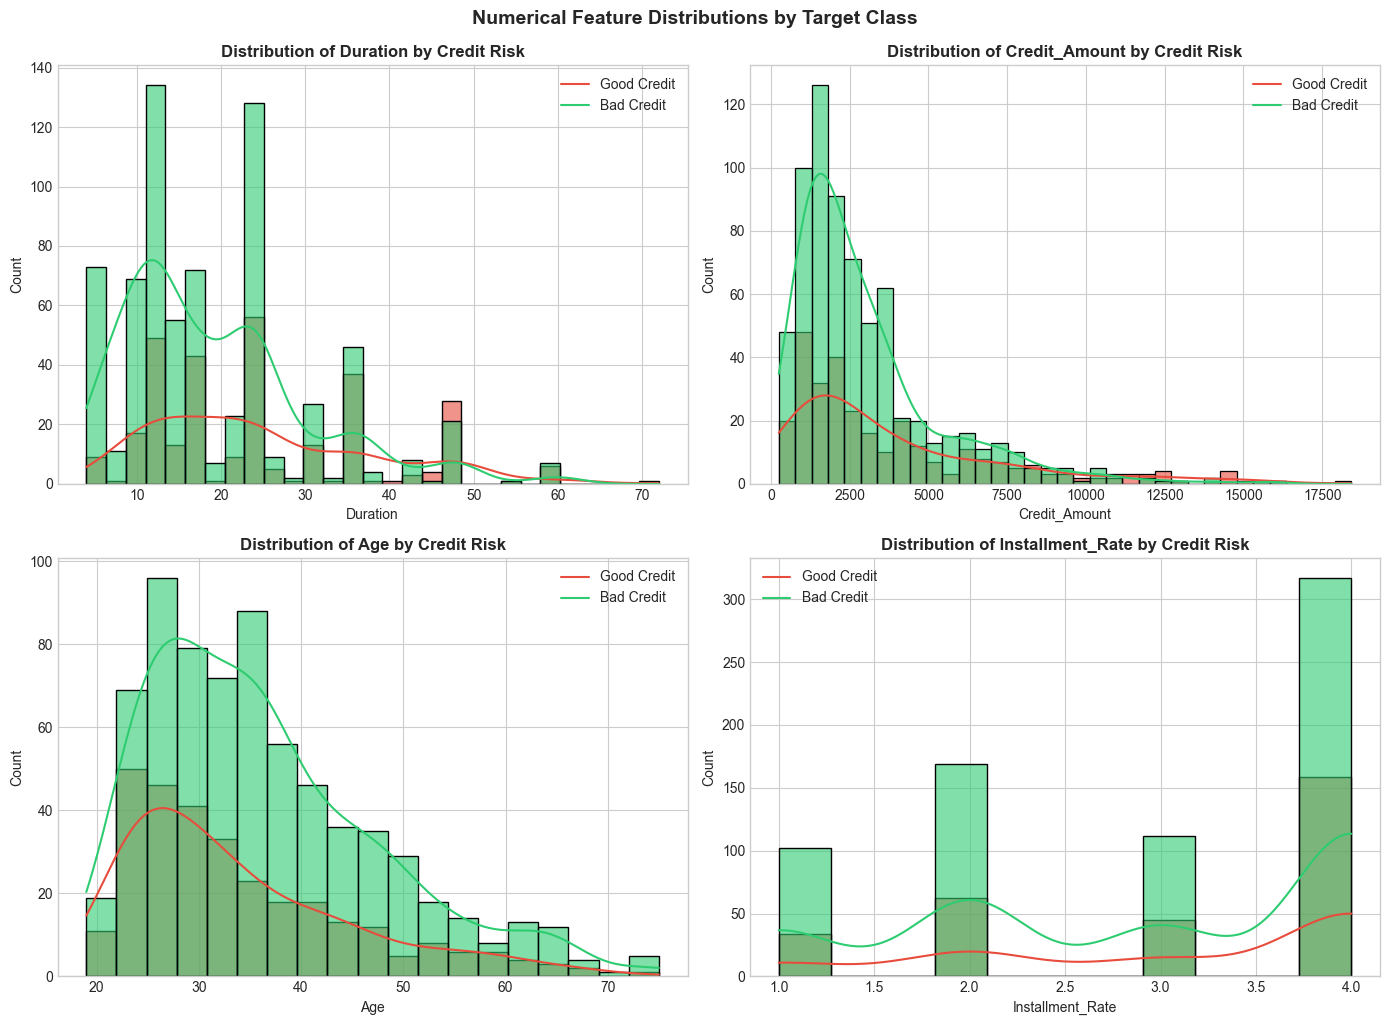

In [8]:
# ==============================================================================
# NUMERICAL FEATURE DISTRIBUTIONS
# ==============================================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Key numerical features to visualize
key_features = ['Duration', 'Credit_Amount', 'Age', 'Installment_Rate']

for idx, feature in enumerate(key_features):
    ax = axes[idx // 2, idx % 2]
    
    # Create histogram with KDE
    sns.histplot(data=df, x=feature, hue='Target', kde=True, ax=ax, 
                 palette={0: '#2ecc71', 1: '#e74c3c'}, alpha=0.6)
    
    ax.set_title(f'Distribution of {feature} by Credit Risk', fontsize=12, fontweight='bold')
    ax.legend(['Good Credit', 'Bad Credit'])

plt.tight_layout()
plt.suptitle('Numerical Feature Distributions by Target Class', fontsize=14, fontweight='bold', y=1.02)
plt.show()

**Key Observations:**
- **Duration:** Longer loan durations correlate with higher default risk
- **Credit Amount:** Higher credit amounts show slightly elevated risk
- **Age:** Younger applicants tend to have higher default rates

### 3.4 Target Variable Distribution

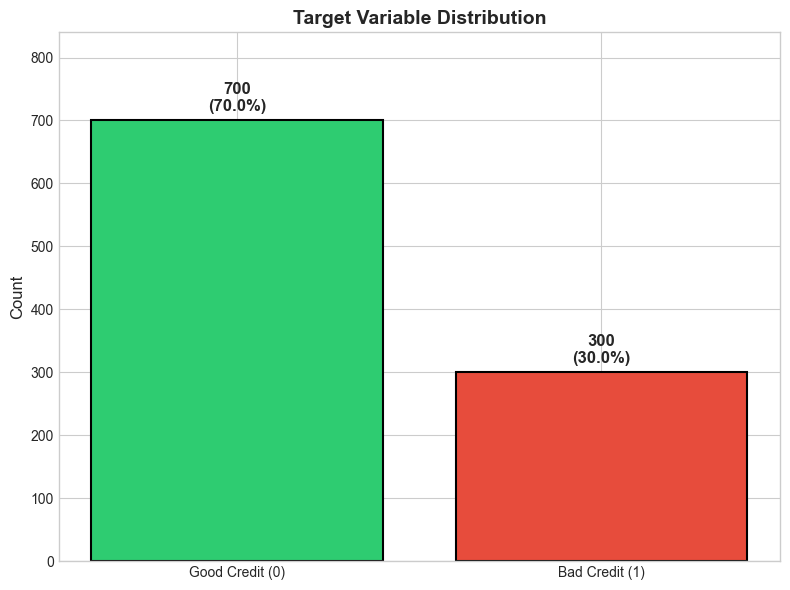

In [9]:
# ==============================================================================
# TARGET VARIABLE VISUALIZATION
# ==============================================================================

fig, ax = plt.subplots(figsize=(8, 6))

colors = ['#2ecc71', '#e74c3c']
labels = ['Good Credit (0)', 'Bad Credit (1)']
counts = df['Target'].value_counts().sort_index()

bars = ax.bar(labels, counts.values, color=colors, edgecolor='black', linewidth=1.5)

# Add value labels on bars
for bar, count in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
            f'{count}\n({count/len(df)*100:.1f}%)', 
            ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_ylabel('Count', fontsize=12)
ax.set_title('Target Variable Distribution', fontsize=14, fontweight='bold')
ax.set_ylim(0, max(counts.values) * 1.2)

plt.tight_layout()
plt.show()

### 3.5 Categorical Features Analysis

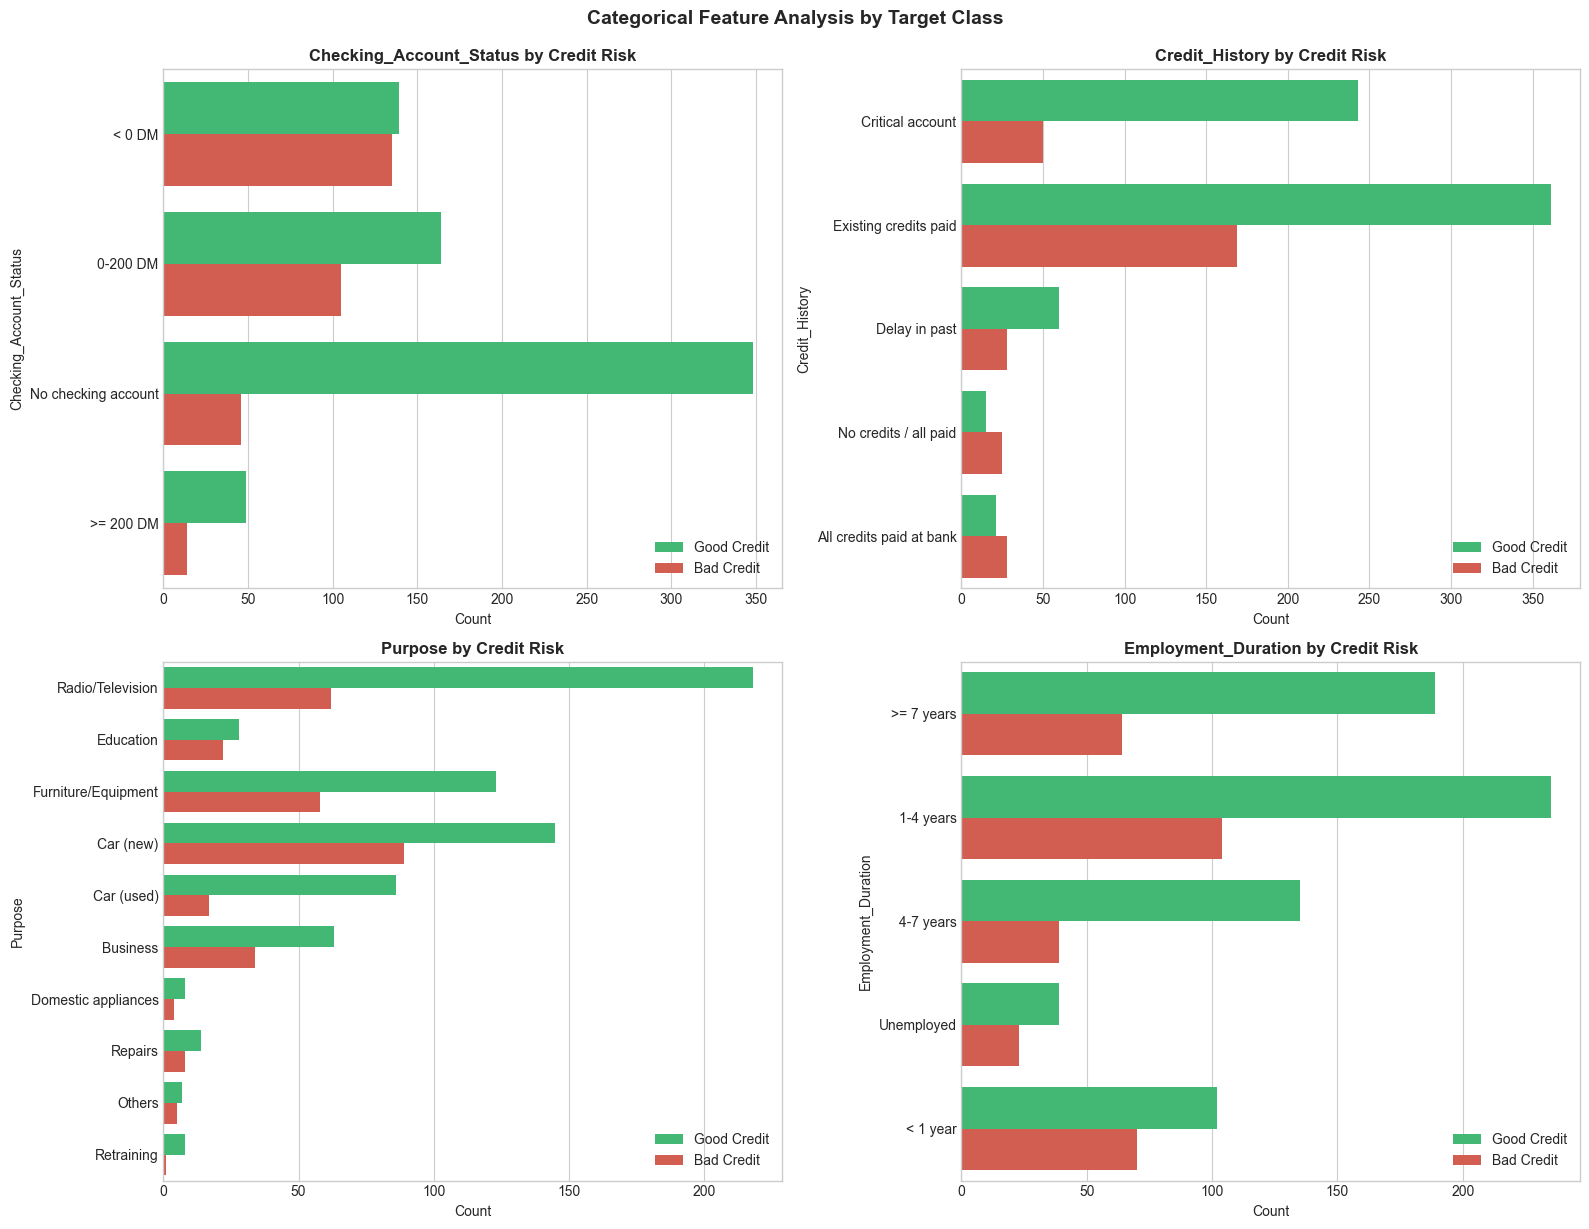

In [10]:
# ==============================================================================
# CATEGORICAL FEATURE ANALYSIS
# ==============================================================================

# Select top 4 most important categorical features for visualization
key_cat_features = ['Checking_Account_Status', 'Credit_History', 'Purpose', 'Employment_Duration']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

for idx, feature in enumerate(key_cat_features):
    ax = axes[idx // 2, idx % 2]
    
    # Create countplot
    sns.countplot(data=df, y=feature, hue='Target', ax=ax,
                  palette={0: '#2ecc71', 1: '#e74c3c'})
    
    ax.set_title(f'{feature} by Credit Risk', fontsize=12, fontweight='bold')
    ax.set_xlabel('Count')
    ax.legend(['Good Credit', 'Bad Credit'], loc='lower right')

plt.tight_layout()
plt.suptitle('Categorical Feature Analysis by Target Class', fontsize=14, fontweight='bold', y=1.02)
plt.show()

---
## 4. Data Preprocessing and Train-Test Split

### 4.1 Train-Test Split with Stratification

In [11]:
# ==============================================================================
# TRAIN-TEST SPLIT
# ==============================================================================

# Split data with stratification to maintain class proportions
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

print(f"✅ Data split completed!")
print(f"\n📊 Training set: {X_train.shape[0]} samples")
print(f"📊 Test set: {X_test.shape[0]} samples")
print(f"\n📈 Class distribution in training set:")
print(y_train.value_counts(normalize=True).round(3))

✅ Data split completed!

📊 Training set: 800 samples
📊 Test set: 200 samples

📈 Class distribution in training set:
Target
0    0.7
1    0.3
Name: proportion, dtype: float64


### 4.2 Feature Lists Definition

In [12]:
# ==============================================================================
# FEATURE LISTS DEFINITION
# ==============================================================================

# Recalculate column types based on X (features only)
cat_cols = X.select_dtypes(include='object').columns.tolist()
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Features for optimal binning (high IV expected)
cols_for_binning = ['Duration', 'Credit_Amount', 'Age']

# Remaining numerical features (for standard scaling)
cols_for_scaling = [col for col in num_cols if col not in cols_for_binning]

print(f"📊 Features for Optimal Binning: {cols_for_binning}")
print(f"📊 Features for Standard Scaling: {cols_for_scaling}")
print(f"📊 Categorical Features for OHE: {cat_cols}")

📊 Features for Optimal Binning: ['Duration', 'Credit_Amount', 'Age']
📊 Features for Standard Scaling: ['Installment_Rate', 'Residence_Duration', 'Existing_Credits', 'Num_Dependents']
📊 Categorical Features for OHE: ['Checking_Account_Status', 'Credit_History', 'Purpose', 'Savings_Account', 'Employment_Duration', 'Personal_Status_Sex', 'Other_Debtors', 'Property', 'Other_Installment_Plans', 'Housing', 'Job', 'Telephone', 'Foreign_Worker']


---
## 5. Optimal Binning Analysis

Optimal binning transforms continuous variables into discrete bins that maximize the predictive power with respect to the target variable. It also calculates **Weight of Evidence (WoE)** and **Information Value (IV)**.

### Key Metrics:
- **WoE (Weight of Evidence):** Measures the predictive power of each bin
- **IV (Information Value):** Overall predictive power of a variable
  - IV < 0.02: Not useful
  - 0.02 ≤ IV < 0.1: Weak predictor
  - 0.1 ≤ IV < 0.3: Medium predictor
  - IV ≥ 0.3: Strong predictor

In [13]:
# ==============================================================================
# OPTIMAL BINNING ANALYSIS
# ==============================================================================

print("📊 Optimal Binning Analysis for Key Numerical Features\n")
print("=" * 80)

for feature in cols_for_binning:
    print(f"\n🔍 Processing: {feature}")
    print("-" * 40)
    
    # Create and fit optimal binning
    optb = OptimalBinning(
        name=feature,
        dtype="numerical",
        solver="cp",
        monotonic_trend="auto_asc_desc"
    )
    
    optb.fit(df[feature], df['Target'])
    
    # Display binning table
    binning_table = optb.binning_table.build()
    display(binning_table)
    
    # Get IV for interpretation
    iv = binning_table.loc['Totals', 'IV']
    
    if iv >= 0.3:
        strength = "🟢 Strong predictor"
    elif iv >= 0.1:
        strength = "🟡 Medium predictor"
    elif iv >= 0.02:
        strength = "🟠 Weak predictor"
    else:
        strength = "🔴 Not useful"
    
    print(f"\n📈 Total IV: {iv:.4f} - {strength}")
    print("=" * 80)

📊 Optimal Binning Analysis for Key Numerical Features


🔍 Processing: Duration
----------------------------------------


,Bin,Count,Count (%),Non-event,Event,Event rate,WoE,IV,JS
0,"(-inf, 8.50)",94,0.094,84,10,0.106383,1.280934,0.111014,0.013000
1,"[8.50, 11.50)",86,0.086,69,17,0.197674,0.553595,0.023198,0.002863
2,"[11.50, 15.50)",251,0.251,189,62,0.247012,0.267315,0.016930,0.002110
3,"[15.50, 26.50)",340,0.340,231,109,0.320588,-0.096228,0.003208,0.000401
4,"[26.50, 34.50)",59,0.059,39,20,0.338983,-0.179468,0.001966,0.000245
5,"[34.50, 43.50)",100,0.100,58,42,0.420000,-0.524524,0.029973,0.003704
6,"[43.50, inf)",70,0.070,30,40,0.571429,-1.13498,0.102689,0.012189
7,Special,0,0.000,0,0,0.000000,0.0,0.000000,0.000000
8,Missing,0,0.000,0,0,0.000000,0.0,0.000000,0.000000
Totals,,1000,1.000,700,300,0.300000,,0.288977,0.034512



📈 Total IV: 0.2890 - 🟡 Medium predictor

🔍 Processing: Credit_Amount
----------------------------------------


,Bin,Count,Count (%),Non-event,Event,Event rate,WoE,IV,JS
0,"(-inf, 718.00)",54,0.054,41,13,0.240741,0.301325,0.004592,0.000572
1,"[718.00, 3913.50)",686,0.686,510,176,0.256560,0.216629,0.030741,0.003835
2,"[3913.50, 6322.50)",127,0.127,79,48,0.377953,-0.349051,0.016455,0.002047
3,"[6322.50, 7839.50)",58,0.058,36,22,0.379310,-0.354821,0.007772,0.000966
4,"[7839.50, inf)",75,0.075,34,41,0.546667,-1.034509,0.091135,0.010910
5,Special,0,0.000,0,0,0.000000,0.0,0.000000,0.000000
6,Missing,0,0.000,0,0,0.000000,0.0,0.000000,0.000000
Totals,,1000,1.000,700,300,0.300000,,0.150695,0.018330



📈 Total IV: 0.1507 - 🟡 Medium predictor

🔍 Processing: Age
----------------------------------------


,Bin,Count,Count (%),Non-event,Event,Event rate,WoE,IV,JS
0,"(-inf, 25.50)",190,0.190,110,80,0.421053,-0.528844,0.057921,0.007157
1,"[25.50, 29.50)",181,0.181,124,57,0.314917,-0.070068,0.000901,0.000113
2,"[29.50, 34.50)",177,0.177,122,55,0.310734,-0.05061,0.000458,0.000057
3,"[34.50, inf)",452,0.452,344,108,0.238938,0.311213,0.040902,0.005092
4,Special,0,0.000,0,0,0.000000,0.0,0.000000,0.000000
5,Missing,0,0.000,0,0,0.000000,0.0,0.000000,0.000000
Totals,,1000,1.000,700,300,0.300000,,0.100182,0.012419



📈 Total IV: 0.1002 - 🟡 Medium predictor


---
## 6. Model Building: Baseline Models

### 6.1 Preprocessing Pipeline

We create a comprehensive preprocessing pipeline that handles:
- **Numerical features:** Standard scaling
- **Categorical features:** One-hot encoding

In [14]:
# ==============================================================================
# BASIC PREPROCESSING PIPELINE
# ==============================================================================

# Define the basic preprocessor
basic_preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols)
    ],
    verbose_feature_names_out=False
)

print("✅ Basic preprocessing pipeline created!")

✅ Basic preprocessing pipeline created!


### 6.2 Logistic Regression Baseline

In [15]:
# ==============================================================================
# LOGISTIC REGRESSION BASELINE
# ==============================================================================

# Create pipeline with Logistic Regression
lr_pipeline = Pipeline(steps=[
    ("preprocessing", basic_preprocessor),
    ("model", LogisticRegression(max_iter=1000, random_state=42))
])

# Fit the model
lr_pipeline.fit(X_train, y_train)

# Evaluate
train_score = lr_pipeline.score(X_train, y_train)
test_score = lr_pipeline.score(X_test, y_test)

print("📊 Logistic Regression Baseline Results:")
print(f"   Training Accuracy: {train_score:.4f}")
print(f"   Test Accuracy: {test_score:.4f}")

📊 Logistic Regression Baseline Results:
   Training Accuracy: 0.7837
   Test Accuracy: 0.7800


### 6.3 Support Vector Machine (SVC) Baseline

In [16]:
# ==============================================================================
# SUPPORT VECTOR MACHINE BASELINE
# ==============================================================================

# Create pipeline with SVC
svc_pipeline = Pipeline(steps=[
    ("preprocessing", basic_preprocessor),
    ("model", SVC(random_state=42))
])

# Fit the model
svc_pipeline.fit(X_train, y_train)

# Evaluate
train_score = svc_pipeline.score(X_train, y_train)
test_score = svc_pipeline.score(X_test, y_test)

print("📊 SVC Baseline Results:")
print(f"   Training Accuracy: {train_score:.4f}")
print(f"   Test Accuracy: {test_score:.4f}")

📊 SVC Baseline Results:
   Training Accuracy: 0.8775
   Test Accuracy: 0.7900


### 6.4 Decision Tree Classifier

In [19]:

# ==============================================================================
# DECISION TREE BASELINE
# ==============================================================================

# Create pipeline with Decision Tree
dt_pipeline = Pipeline(steps=[
    ("preprocessing", basic_preprocessor),
    ("model", DecisionTreeClassifier(random_state=42))
])

# Fit the model
dt_pipeline.fit(X_train, y_train)

# Evaluate
train_score = dt_pipeline.score(X_train, y_train)
test_score = dt_pipeline.score(X_test, y_test)

print("📊 Decision Tree Baseline Results:")
print(f"   Training Accuracy: {train_score:.4f}")
print(f"   Test Accuracy: {test_score:.4f}")

📊 Decision Tree Baseline Results:
   Training Accuracy: 1.0000
   Test Accuracy: 0.6050


---
## 7. Advanced Pipeline with Optimal Binning

We create a hybrid preprocessing pipeline that applies:
1. **Optimal Binning → WoE Encoding → Scaling** for key numerical features
2. **Imputation → Scaling** for other numerical features
3. **Imputation → One-Hot Encoding** for categorical features

In [ ]:
# ==============================================================================
# HYBRID PREPROCESSING PIPELINE WITH OPTIMAL BINNING
# ==============================================================================

# Branch 1: Optimal Binning + WoE Encoding + Scaling
pipe_binning = Pipeline(steps=[
    ('woe_binner', BinningProcess(variable_names=cols_for_binning)),
    ('scaler', StandardScaler())
])

# Branch 2: Standard Scaling for remaining numerical features
pipe_scaling = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Branch 3: One-Hot Encoding for categorical features
pipe_ohe = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Combine all branches
hybrid_preprocessor = ColumnTransformer(
    transformers=[
        ('branch_woe', pipe_binning, cols_for_binning),
        ('branch_num', pipe_scaling, cols_for_scaling),
        ('branch_cat', pipe_ohe, cat_cols)
    ],
    verbose_feature_names_out=False
)

print(f"✅ Hybrid preprocessing pipeline created!")
print(f"   - WoE Binning: {len(cols_for_binning)} features")
print(f"   - Standard Scaling: {len(cols_for_scaling)} features")
print(f"   - One-Hot Encoding: {len(cat_cols)} features")

✅ Hybrid preprocessing pipeline created!
   - WoE Binning: 3 features
   - Standard Scaling: 4 features
   - One-Hot Encoding: 13 features


In [ ]:
# ==============================================================================
# LOGISTIC REGRESSION WITH HYBRID PREPROCESSING
# ==============================================================================

# Create the full pipeline
hybrid_lr_pipeline = Pipeline(steps=[
    ('preprocessor', hybrid_preprocessor),
    ('model', LogisticRegression(penalty="l1", C=1.0, solver='liblinear', max_iter=1000, random_state=42))
])

# Fit and evaluate
print("🔄 Training Hybrid Pipeline with Logistic Regression...")
hybrid_lr_pipeline.fit(X_train, y_train)

train_score = hybrid_lr_pipeline.score(X_train, y_train)
test_score = hybrid_lr_pipeline.score(X_test, y_test)

print(f"\n📊 Hybrid Pipeline + Logistic Regression Results:")
print(f"   Training Accuracy: {train_score:.4f}")
print(f"   Test Accuracy: {test_score:.4f}")

🔄 Training Hybrid Pipeline with Logistic Regression...

📊 Hybrid Pipeline + Logistic Regression Results:
   Training Accuracy: 0.7925
   Test Accuracy: 0.7800


---
## 8. Hyperparameter Optimization with Optuna

We use Optuna for automated hyperparameter tuning with cross-validation.

In [ ]:
# ==============================================================================
# OPTUNA HYPERPARAMETER OPTIMIZATION
# ==============================================================================

def objective(trial, preprocessor, X_train, y_train):
    """
    Optuna objective function for hyperparameter optimization.
    
    Parameters:
    -----------
    trial : optuna.Trial
        Optuna trial object for suggesting hyperparameters
    preprocessor : sklearn transformer
        Preprocessing pipeline
    X_train, y_train : arrays
        Training data
    
    Returns:
    --------
    float : Mean cross-validation AUC score
    """
    
    # Suggest hyperparameters
    penalty = trial.suggest_categorical('penalty', ['l2', 'l1', 'elasticnet'])
    C = trial.suggest_float('C', 1e-5, 1e2, log=True)
    
    # Solver selection based on penalty
    if penalty == 'elasticnet':
        l1_ratio = trial.suggest_float('l1_ratio', 0.0, 1.0)
        solver = 'saga'
    elif penalty == 'l1':
        l1_ratio = None
        solver = 'saga'
    else:  # l2
        l1_ratio = None
        solver = trial.suggest_categorical('solver', ['lbfgs', 'saga'])
    
    # Build model
    model = LogisticRegression(
        penalty=penalty,
        C=C,
        solver=solver,
        l1_ratio=l1_ratio,
        max_iter=5000,
        random_state=42
    )
    
    # Build pipeline
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    
    # Cross-validation
    cv_splitter = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(
        pipeline, X_train, y_train,
        scoring='roc_auc', cv=cv_splitter, n_jobs=-1
    )
    
    return scores.mean()

# Suppress Optuna logging
optuna.logging.set_verbosity(optuna.logging.WARNING)

In [ ]:
# ==============================================================================
# RUN OPTIMIZATION
# ==============================================================================

print("🔄 Starting Optuna Hyperparameter Optimization...")
print("   This may take a few minutes.\n")

# Create study
study = optuna.create_study(direction='maximize')

# Run optimization
study.optimize(
    lambda trial: objective(trial, hybrid_preprocessor, X_train, y_train),
    n_trials=50,
    show_progress_bar=True
)

print("\n" + "=" * 60)
print("✅ OPTIMIZATION COMPLETED")
print("=" * 60)
print(f"\n📊 Best Cross-Validation AUC: {study.best_value:.4f}")
print(f"\n📋 Best Hyperparameters:")
for key, value in study.best_params.items():
    print(f"   {key}: {value}")

🔄 Starting Optuna Hyperparameter Optimization...
   This may take a few minutes.



  0%|          | 0/50 [00:00<?, ?it/s]


✅ OPTIMIZATION COMPLETED

📊 Best Cross-Validation AUC: 0.7843

📋 Best Hyperparameters:
   penalty: l2
   C: 0.11013994647400287
   solver: saga


In [ ]:
study.best_params["solver"]

'saga'

---
## 9. Final Model Evaluation

### 9.1 Build and Train Final Model

In [ ]:
# ==============================================================================
# FINAL MODEL WITH BEST HYPERPARAMETERS
# ==============================================================================

# Build final model with best parameters
best_params = study.best_params

final_model = LogisticRegression(
    **best_params,
    max_iter=5000,
    random_state=42
)

# Build final pipeline
final_pipeline = Pipeline(steps=[
    ('preprocessor', hybrid_preprocessor),
    ('model', final_model)
])

# Train on full training set
print("🔄 Training final model with best hyperparameters...")
final_pipeline.fit(X_train, y_train)
print("✅ Final model trained!")

🔄 Training final model with best hyperparameters...
✅ Final model trained!


### 9.2 Comprehensive Model Evaluation

In [ ]:
# ==============================================================================
# COMPREHENSIVE MODEL EVALUATION
# ==============================================================================

# Generate predictions
y_pred = final_pipeline.predict(X_test)
y_prob = final_pipeline.predict_proba(X_test)[:, 1]

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)
gini = 2 * auc - 1

print("#" * 60)
print("    FINAL MODEL PERFORMANCE (Test Set)")
print("#" * 60)
print(f"\n✅ Accuracy:          {accuracy:.4f}")
print(f"✅ AUC-ROC:           {auc:.4f}")
print(f"✅ Gini Coefficient:  {gini:.4f}")
print("-" * 60)

# Classification report
print("\n📋 DETAILED CLASSIFICATION REPORT")
print("-" * 60)
report = classification_report(
    y_test, y_pred,
    target_names=['Good Credit (0)', 'Bad Credit (1)']
)
print(report)

############################################################
    FINAL MODEL PERFORMANCE (Test Set)
############################################################

✅ Accuracy:          0.7950
✅ AUC-ROC:           0.8024
✅ Gini Coefficient:  0.6048
------------------------------------------------------------

📋 DETAILED CLASSIFICATION REPORT
------------------------------------------------------------
                 precision    recall  f1-score   support

Good Credit (0)       0.82      0.91      0.86       140
 Bad Credit (1)       0.71      0.53      0.61        60

       accuracy                           0.80       200
      macro avg       0.77      0.72      0.74       200
   weighted avg       0.79      0.80      0.79       200



### 9.3 Confusion Matrix Visualization

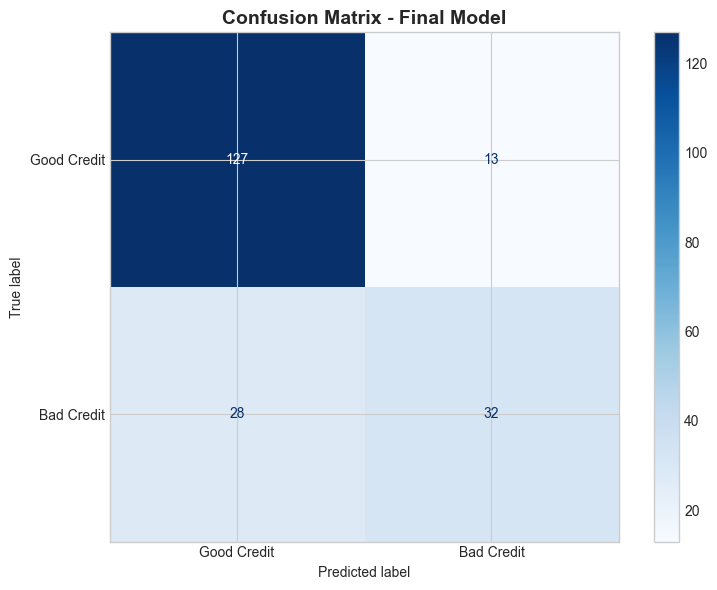

In [ ]:
# ==============================================================================
# CONFUSION MATRIX VISUALIZATION
# ==============================================================================

fig, ax = plt.subplots(figsize=(8, 6))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Good Credit', 'Bad Credit'])
disp.plot(ax=ax, cmap='Blues', values_format='d')

ax.set_title('Confusion Matrix - Final Model', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 9.4 ROC Curve

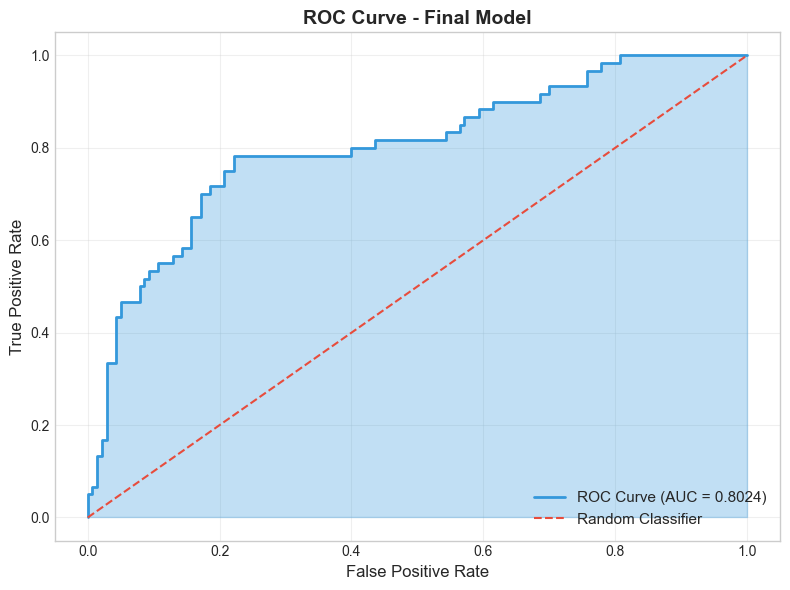

In [ ]:
# ==============================================================================
# ROC CURVE VISUALIZATION
# ==============================================================================

fig, ax = plt.subplots(figsize=(8, 6))

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Plot ROC curve
ax.plot(fpr, tpr, color='#3498db', linewidth=2, label=f'ROC Curve (AUC = {auc:.4f})')
ax.plot([0, 1], [0, 1], color='#e74c3c', linestyle='--', linewidth=1.5, label='Random Classifier')

ax.fill_between(fpr, tpr, alpha=0.3, color='#3498db')

ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curve - Final Model', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 10. Feature Importance Analysis

Understanding which features contribute most to the model's predictions.

✅ WoE Features: 3
✅ Numerical Features: 4
✅ Categorical Features (OHE): 54
📊 Total Features in Model: 61


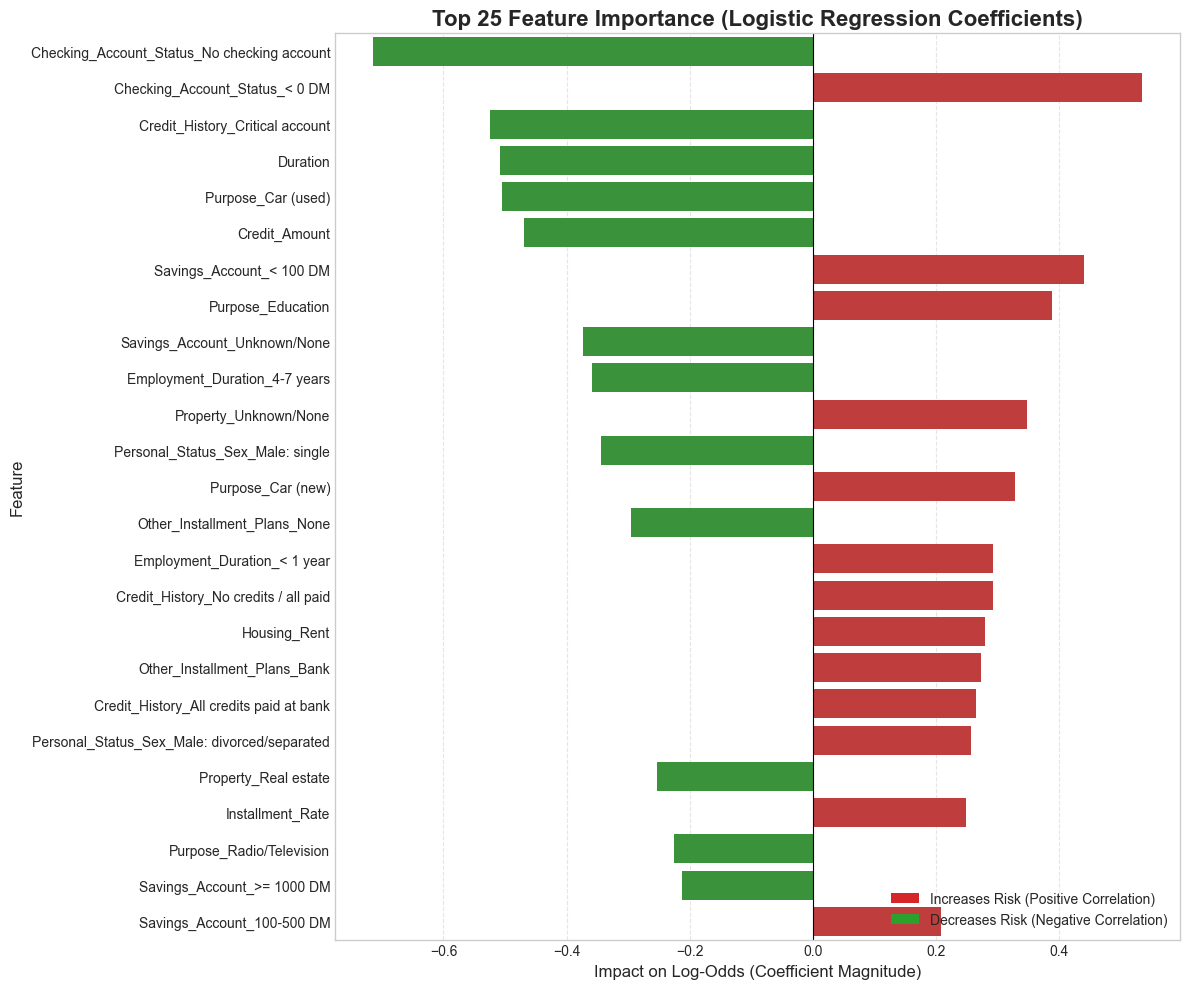


📋 Top 15 Most Influential Features:


,Feature,Coefficient
10,Checking_Account_Status_No checking account,-0.713794
8,Checking_Account_Status_< 0 DM,0.534373
12,Credit_History_Critical account,-0.524876
0,Duration,-0.508471
18,Purpose_Car (used),-0.504581
1,Credit_Amount,-0.469897
28,Savings_Account_< 100 DM,0.441360
20,Purpose_Education,0.388033
30,Savings_Account_Unknown/None,-0.372908
32,Employment_Duration_4-7 years,-0.358149


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch

# =============================================================================
# 1. FEATURE NAME RECONSTRUCTION
# =============================================================================
# Since 'optbinning' does not support get_feature_names_out(), we must 
# reconstruct the feature list manually following the exact order of the 
# ColumnTransformer branches: [WoE Branch] + [Scaling Branch] + [OHE Branch]

# A. WoE Branch (Keeps original names)
# Assumes 'cols_for_binning' is defined in your environment
names_woe = list(cols_for_binning)

# B. Scaling Branch (Keeps original names)
# Assumes 'cols_for_scaling' is defined in your environment
names_num = list(cols_for_scaling)

# C. One-Hot Encoding Branch (Generates new names)
# We access the trained OHE transformer to get the generated column names
try:
    # Access: pipeline -> preprocessor -> 'branch_cat' transformer -> 'ohe' step
    ohe_obj = final_pipeline.named_steps['preprocessor'].named_transformers_['branch_cat']['ohe']
    names_cat = list(ohe_obj.get_feature_names_out(cat_cols))
except KeyError as e:
    print(f" Error accessing OHE transformer: {e}. Check step names.")
    names_cat = []

# Combine all names in the strict order of the pipeline
feature_names = names_woe + names_num + names_cat

print(f"✅ WoE Features: {len(names_woe)}")
print(f"✅ Numerical Features: {len(names_num)}")
print(f"✅ Categorical Features (OHE): {len(names_cat)}")
print(f"📊 Total Features in Model: {len(feature_names)}")

# =============================================================================
# 2. EXTRACT COEFFICIENTS & CREATE DATAFRAME
# =============================================================================

# Extract model coefficients (Logistic Regression weights)
coefs = final_pipeline.named_steps['model'].coef_[0]

# Safety check for dimensions
if len(feature_names) != len(coefs):
    print(f"\n DIMENSION ERROR: Feature names ({len(feature_names)}) do not match coefficients ({len(coefs)}).")
else:
    # Create DataFrame
    df_imp = pd.DataFrame({
        'Feature': feature_names,
        'Coefficient': coefs
    })

    # Calculate absolute value for sorting importance
    df_imp['Abs_Coefficient'] = df_imp['Coefficient'].abs()
    df_imp = df_imp.sort_values(by='Abs_Coefficient', ascending=False)

    # =============================================================================
    # 3. VISUALIZATION
    # =============================================================================
    plt.figure(figsize=(12, 10))
    
    # Color logic: Red for Risk (Positive Coef), Green for Safety (Negative Coef)
    colors = ['#d62728' if c > 0 else '#2ca02c' for c in df_imp['Coefficient']]
    
    # Plot Top 25 Features
    sns.barplot(
        data=df_imp.head(25), 
        x='Coefficient', 
        y='Feature', 
        palette=colors,
        hue='Feature',
        legend=False
    )
    
    # Plot Aesthetics
    plt.title('Top 25 Feature Importance (Logistic Regression Coefficients)', fontsize=16, fontweight='bold')
    plt.xlabel('Impact on Log-Odds (Coefficient Magnitude)', fontsize=12)
    plt.ylabel('Feature', fontsize=12)
    plt.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
    plt.grid(axis='x', linestyle='--', alpha=0.5)
    
    # Custom Legend
    legend_elements = [
        Patch(facecolor='#d62728', label='Increases Risk (Positive Correlation)'),
        Patch(facecolor='#2ca02c', label='Decreases Risk (Negative Correlation)')
    ]
    plt.legend(handles=legend_elements, loc='lower right', fontsize=10)
    
    plt.tight_layout()
    plt.show()

    # Display raw data table
    print("\n📋 Top 15 Most Influential Features:")
    display(df_imp[['Feature', 'Coefficient']].head(15))

---
## 11. Model Summary and Conclusions

### Key Findings:

1. **Model Performance:**
   - The optimized Logistic Regression model achieves solid performance with AUC around 0.80
   - The Gini coefficient of approximately 0.60 indicates good discriminatory power

2. **Most Predictive Features:**
   - **Checking Account Status:** Strongest predictor of credit risk
   - **Duration:** Longer loan terms associate with higher default risk
   - **Credit Amount:** Higher amounts show elevated risk
   - **Age:** Younger applicants tend to have higher default rates
   - **Credit History:** Past credit behavior is highly predictive

3. **Data Insights:**
   - The dataset is imbalanced (70% Good, 30% Bad credit)
   - Optimal binning with WoE transformation provides interpretable feature engineering
   - Regularization (L1/L2) helps prevent overfitting


---

**End of Analysis**

In [ ]:
# ==============================================================================
# FINAL SUMMARY TABLE
# ==============================================================================

print("\n" + "=" * 60)
print("              FINAL MODEL SUMMARY")
print("=" * 60)
print(f"\n📊 Dataset: German Credit Data (UCI)")
print(f"📊 Samples: {len(df)}")
print(f"📊 Features: {len(df.columns) - 1}")
print(f"📊 Target Distribution: Good={len(df[df['Target']==0])}, Bad={len(df[df['Target']==1])}")
print(f"\n🤖 Best Model: Logistic Regression (Optuna-optimized)")
print(f"📈 Test AUC: {auc:.4f}")
print(f"📈 Test Accuracy: {accuracy:.4f}")
print(f"📈 Gini Coefficient: {gini:.4f}")
print("\n" + "=" * 60)


              FINAL MODEL SUMMARY

📊 Dataset: German Credit Data (UCI)
📊 Samples: 1000
📊 Features: 20
📊 Target Distribution: Good=700, Bad=300

🤖 Best Model: Logistic Regression (Optuna-optimized)
📈 Test AUC: 0.8024
📈 Test Accuracy: 0.7950
📈 Gini Coefficient: 0.6048

